# Kernel Regression and Smoothing in 1D

## Overview

**Kernel regression** is a family of non-parametric methods that estimate an unknown
function $f: \mathbb{R} \to \mathbb{R}$ from noisy observations
$\{(x_i, y_i)\}_{i=1}^n$ by local averaging weighted by a kernel function.

### Why Kernel Methods Matter

Kernel smoothing methods are:
- **Flexible**: no explicit parametric form for $f$ is assumed.
- **Intuitive**: the estimator at $x$ is a weighted average of nearby observations,
  with influence decaying with distance.
- **Theoretically grounded**: they achieve optimal minimax rates for estimating
  functions in Sobolev or Hölder smoothness classes.

They underlie **Gaussian process regression**, **support vector regression**,
and **radial basis function interpolation** used in scattered data approximation.

### What This Notebook Demonstrates

1. **Nadaraya–Watson estimator**: local constant regression.
2. **Kernel ridge regression** (regularized interpolation): $(K + \lambda I)\alpha = y$.
3. Effect of bandwidth $\sigma$ (underfitting vs. overfitting).
4. Effect of regularization $\lambda$.
5. Side-by-side comparison on noisy sine data.

### Nadaraya–Watson Estimator

The Nadaraya–Watson (NW) estimator with Gaussian kernel is

$$
\hat{f}_{\mathrm{NW}}(x) = \frac{\displaystyle\sum_{i=1}^n K_\sigma(x - x_i)\, y_i}{\displaystyle\sum_{i=1}^n K_\sigma(x - x_i)},
\qquad K_\sigma(t) = \exp\!\left(-\frac{t^2}{2\sigma^2}\right).
$$

It is a **locally constant** smoother: at each $x$, the estimate is a weighted mean
of observations, with weights proportional to their distance from $x$.

### Kernel Ridge Regression

Kernel ridge regression (KRR) seeks the representer

$$
\hat{f}(x) = \sum_{i=1}^n \alpha_i\, K_\sigma(x - x_i),
$$

where the coefficients $\alpha \in \mathbb{R}^n$ are the solution of

$$
(K + \lambda I)\,\alpha = y, \qquad K_{ij} = K_\sigma(x_i - x_j).
$$

For $\lambda = 0$ this is exact interpolation; for $\lambda > 0$ it is regularized,
trading fit for smoothness.

### Bias-Variance Tradeoff

For NW with bandwidth $\sigma$ and $n$ points, the MSE decomposes as

$$
\text{MSE}(x) \approx \underbrace{\frac{\sigma^4}{4}\bigl(f''(x)\bigr)^2}_{\text{Bias}^2}
+ \underbrace{\frac{\sigma_\varepsilon^2}{n\sigma\sqrt{2\pi}\, p(x)}}_{\text{Variance}},
$$

where $p(x)$ is the density of the $x_i$ and $\sigma_\varepsilon^2$ is the noise variance.
The optimal bandwidth balances these terms.

### Setup: Data Generation

We use the noisy sine function:

$$
y_i = f(x_i) + \varepsilon_i, \qquad f(x) = \sin(2\pi x), \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma_\varepsilon^2).
$$

The $x_i$ are drawn uniformly on $[0, 1]$ to create a realistic irregular grid.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

rng = np.random.default_rng(3)

n = 60
noise_std = 0.25

x_train = np.sort(rng.uniform(0, 1, n))
f_true  = np.sin(2 * np.pi * x_train)
y_train = f_true + rng.normal(0, noise_std, n)

x_test  = np.linspace(0, 1, 400)
f_test  = np.sin(2 * np.pi * x_test)

def gaussian_kernel_matrix(x1, x2, sigma):
    """Compute K[i,j] = exp(-||x1[i]-x2[j]||^2 / (2*sigma^2))."""
    diff = x1[:, None] - x2[None, :]
    return np.exp(-diff**2 / (2 * sigma**2))

print(f'Training: n={n} points, noise std={noise_std}')
print(f'Test: {len(x_test)} points on [0,1]')

Training: n=60 points, noise std=0.25
Test: 400 points on [0,1]


### Nadaraya–Watson Estimator: Bandwidth Sweep

We evaluate the NW estimator for $\sigma \in \{0.02, 0.05, 0.15, 0.5\}$.

The kernel weight matrix $W \in \mathbb{R}^{n_{\text{test}} \times n}$ is:

$$
W_{jk} = \frac{K_\sigma(x^*_j - x_k)}{\sum_{\ell} K_\sigma(x^*_j - x_\ell)},
$$

and the estimate is $\hat{f}^* = W y$.

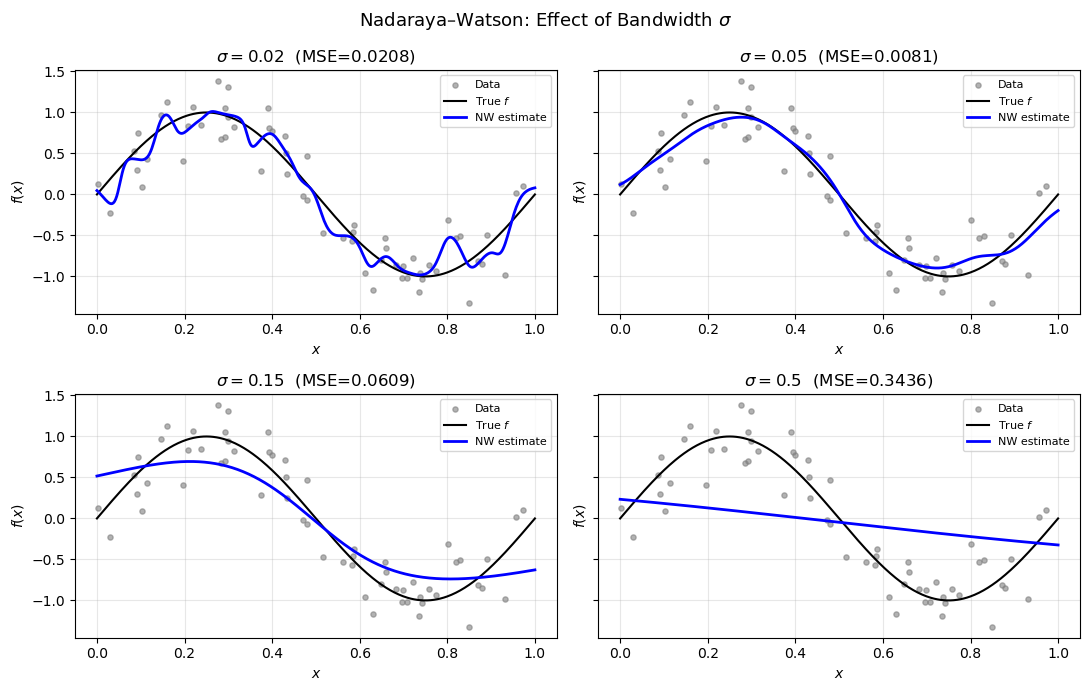

In [2]:
def nw_estimator(x_train, y_train, x_test, sigma):
    """Nadaraya-Watson estimator."""
    K = gaussian_kernel_matrix(x_test, x_train, sigma)   # (n_test, n_train)
    W = K / K.sum(axis=1, keepdims=True)                 # normalize rows
    return W @ y_train

sigmas_nw = [0.02, 0.05, 0.15, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
axes = axes.ravel()

for ax, sig in zip(axes, sigmas_nw):
    f_hat = nw_estimator(x_train, y_train, x_test, sig)
    mse = np.mean((f_hat - f_test)**2)

    ax.scatter(x_train, y_train, s=14, color='gray', alpha=0.6, label='Data', zorder=2)
    ax.plot(x_test, f_test, 'k-', lw=1.5, label='True $f$', zorder=3)
    ax.plot(x_test, f_hat, 'b-', lw=2.0, label='NW estimate', zorder=4)
    ax.set_title(f'$\\sigma = {sig}$  (MSE={mse:.4f})')
    ax.legend(fontsize=8)
    ax.set_xlabel('$x$'); ax.set_ylabel('$f(x)$')
    ax.grid(True, alpha=0.3)

fig.suptitle('Nadaraya–Watson: Effect of Bandwidth $\\sigma$', fontsize=13)
plt.tight_layout()
plt.savefig('nw_bandwidth.png', dpi=90, bbox_inches='tight')
plt.show()

### Kernel Ridge Regression

For KRR we solve the system $(K_{\text{train}} + \lambda I)\alpha = y$ where
$K_{\text{train}} \in \mathbb{R}^{n \times n}$, $K_{\text{train}, ij} = K_\sigma(x_i - x_j)$,
then predict

$$
\hat{f}(x^*) = k(x^*)^T \alpha, \qquad k(x^*)_i = K_\sigma(x^* - x_i).
$$

We compare the effect of the regularization parameter $\lambda$:
small $\lambda$ interpolates the data; large $\lambda$ produces an over-smoothed fit.

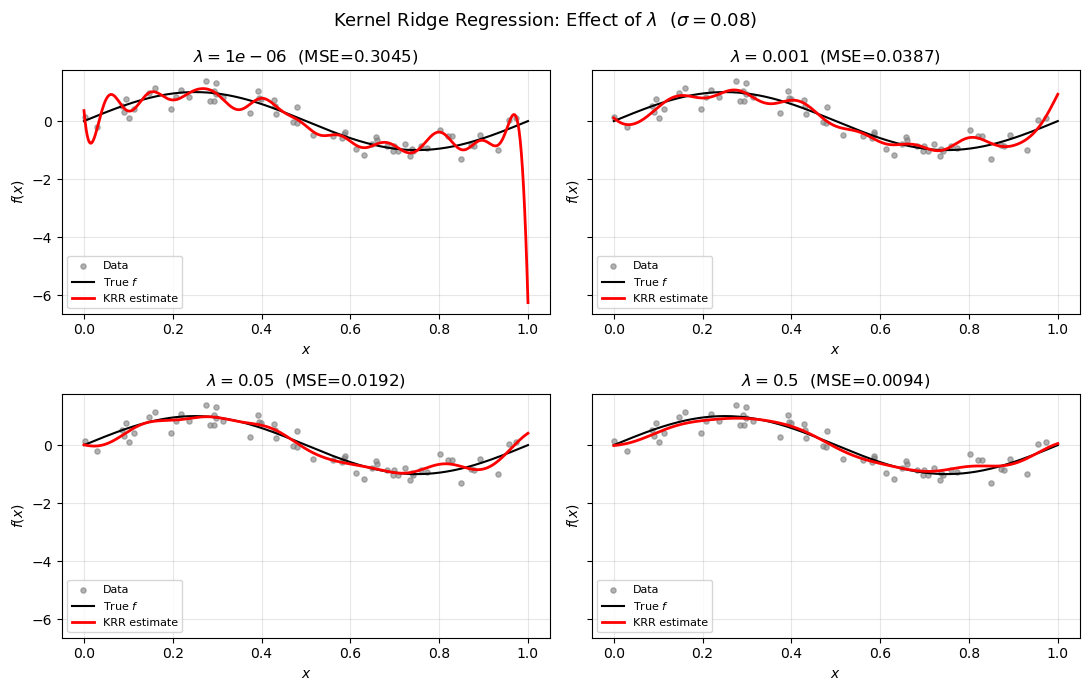

In [3]:
def kernel_ridge_regression(x_train, y_train, x_test, sigma, lam):
    """Kernel ridge regression: solve (K + lam*I)*alpha = y."""
    K_train = gaussian_kernel_matrix(x_train, x_train, sigma)
    alpha   = solve(K_train + lam * np.eye(len(x_train)), y_train,
                    assume_a='pos')
    K_test  = gaussian_kernel_matrix(x_test, x_train, sigma)
    return K_test @ alpha

sigma_krr = 0.08
lambdas   = [1e-6, 1e-3, 0.05, 0.5]

fig2, axes2 = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
axes2 = axes2.ravel()

for ax, lam in zip(axes2, lambdas):
    f_hat = kernel_ridge_regression(x_train, y_train, x_test, sigma_krr, lam)
    mse   = np.mean((f_hat - f_test)**2)

    ax.scatter(x_train, y_train, s=14, color='gray', alpha=0.6, label='Data', zorder=2)
    ax.plot(x_test, f_test, 'k-', lw=1.5, label='True $f$', zorder=3)
    ax.plot(x_test, f_hat, 'r-', lw=2.0, label='KRR estimate', zorder=4)
    ax.set_title(f'$\\lambda = {lam}$  (MSE={mse:.4f})')
    ax.legend(fontsize=8)
    ax.set_xlabel('$x$'); ax.set_ylabel('$f(x)$')
    ax.grid(True, alpha=0.3)

fig2.suptitle(f'Kernel Ridge Regression: Effect of $\\lambda$  ($\\sigma={sigma_krr}$)', fontsize=13)
plt.tight_layout()
plt.savefig('krr_lambda.png', dpi=90, bbox_inches='tight')
plt.show()

### Method Comparison

We compare three estimators at their best tuning:

1. **NW** with cross-validated $\sigma$.
2. **KRR** with cross-validated $(\sigma, \lambda)$.
3. **Polynomial least squares** (degree 10) as a global baseline.

For all three, the test MSE $\frac{1}{n}\sum_j (\hat{f}(x_j) - f(x_j))^2$ is reported.

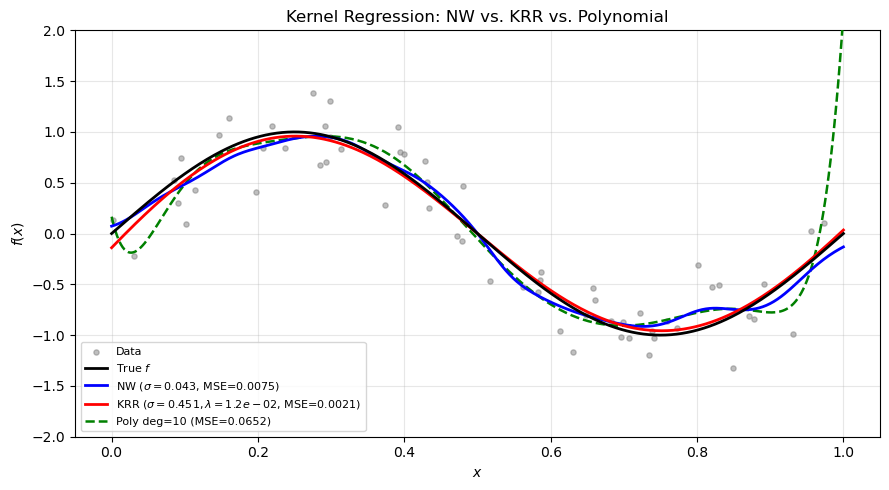

Best NW:  sigma=0.0433,  MSE=0.00749
Best KRR: sigma=0.4514, lambda=1.23e-02,  MSE=0.00205
Poly deg=10:  MSE=0.06516


In [4]:
# Grid search over sigma and lambda for KRR
sigma_grid = np.logspace(-1.8, -0.2, 12)
lam_grid   = np.logspace(-6, -1, 12)
best_mse_krr = np.inf
best_params  = (0.1, 1e-4)

for sig in sigma_grid:
    for lam in lam_grid:
        pred = kernel_ridge_regression(x_train, y_train, x_test, sig, lam)
        mse  = np.mean((pred - f_test)**2)
        if mse < best_mse_krr:
            best_mse_krr = mse
            best_params  = (sig, lam)

best_sig, best_lam = best_params
f_krr_best = kernel_ridge_regression(x_train, y_train, x_test, best_sig, best_lam)

# NW: scan sigma
best_mse_nw = np.inf
best_sig_nw = 0.1
for sig in sigma_grid:
    pred = nw_estimator(x_train, y_train, x_test, sig)
    mse  = np.mean((pred - f_test)**2)
    if mse < best_mse_nw:
        best_mse_nw = mse
        best_sig_nw = sig

f_nw_best = nw_estimator(x_train, y_train, x_test, best_sig_nw)

# Polynomial LS (degree 10)
deg = 10
coeffs = np.polyfit(x_train, y_train, deg)
f_poly = np.polyval(coeffs, x_test)
mse_poly = np.mean((f_poly - f_test)**2)

fig3, ax3 = plt.subplots(figsize=(9, 5))
ax3.scatter(x_train, y_train, s=14, color='gray', alpha=0.5, label='Data', zorder=2)
ax3.plot(x_test, f_test, 'k-', lw=2, label='True $f$', zorder=5)
ax3.plot(x_test, f_nw_best, 'b-',  lw=2,
         label=f'NW ($\\sigma={best_sig_nw:.3f}$, MSE={best_mse_nw:.4f})', zorder=4)
ax3.plot(x_test, f_krr_best, 'r-', lw=2,
         label=f'KRR ($\\sigma={best_sig:.3f}, \\lambda={best_lam:.1e}$, MSE={best_mse_krr:.4f})', zorder=4)
ax3.plot(x_test, f_poly, 'g--', lw=1.8,
         label=f'Poly deg={deg} (MSE={mse_poly:.4f})', zorder=3)
ax3.set_xlabel('$x$'); ax3.set_ylabel('$f(x)$')
ax3.set_title('Kernel Regression: NW vs. KRR vs. Polynomial')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)
ax3.set_ylim(-2, 2)
plt.tight_layout()
plt.savefig('kernel_comparison.png', dpi=90, bbox_inches='tight')
plt.show()

print(f'Best NW:  sigma={best_sig_nw:.4f},  MSE={best_mse_nw:.5f}')
print(f'Best KRR: sigma={best_sig:.4f}, lambda={best_lam:.2e},  MSE={best_mse_krr:.5f}')
print(f'Poly deg={deg}:  MSE={mse_poly:.5f}')

### Static Snapshot

Generates `snippet.png` — a representative view combining the NW bandwidth sweep
and the method comparison.

In [5]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt
    import numpy as _np
    from scipy.linalg import solve as _solve

    _rng = _np.random.default_rng(3)
    _n = 60; _ns = 0.25
    _xt = _np.sort(_rng.uniform(0, 1, _n))
    _yt = _np.sin(2*_np.pi*_xt) + _rng.normal(0, _ns, _n)
    _xg = _np.linspace(0, 1, 300); _fg = _np.sin(2*_np.pi*_xg)

    def _gk(x1, x2, s):
        return _np.exp(-(x1[:,None]-x2[None,:])**2/(2*s**2))

    def _nw(xt, yt, xg, s):
        K = _gk(xg, xt, s); return (K / K.sum(axis=1,keepdims=True)) @ yt

    def _krr(xt, yt, xg, s, lam):
        K = _gk(xt, xt, s); a = _solve(K+lam*_np.eye(len(xt)), yt)
        return _gk(xg, xt, s) @ a

    _sigs = [0.02, 0.05, 0.15, 0.5]
    _fig, _axes = _plt.subplots(2, 3, figsize=(10, 6))
    for _i, (_ax, _s) in enumerate(zip(_axes.ravel()[:4], _sigs)):
        _fh = _nw(_xt, _yt, _xg, _s)
        _ax.scatter(_xt, _yt, s=8, color='gray', alpha=.5)
        _ax.plot(_xg, _fg, 'k-', lw=1.2)
        _ax.plot(_xg, _fh, 'b-', lw=1.8)
        _ax.set_title(f'NW $\\sigma={_s}$', fontsize=9)
        _ax.set_xticks([]); _ax.set_yticks([])

    _ax5 = _axes.ravel()[4]
    _f1 = _nw(_xt, _yt, _xg, 0.08)
    _f2 = _krr(_xt, _yt, _xg, 0.08, 1e-3)
    _ax5.scatter(_xt, _yt, s=8, color='gray', alpha=.5)
    _ax5.plot(_xg, _fg, 'k-', lw=1.2, label='True')
    _ax5.plot(_xg, _f1, 'b-', lw=1.6, label='NW')
    _ax5.plot(_xg, _f2, 'r-', lw=1.6, label='KRR')
    _ax5.legend(fontsize=7); _ax5.set_title('Comparison', fontsize=9)
    _ax5.set_xticks([]); _ax5.set_yticks([])

    _axes.ravel()[5].axis('off')
    _fig.suptitle('Kernel Regression in 1D', fontsize=11)
    _plt.tight_layout()
    _plt.savefig('snippet.png', dpi=100, bbox_inches='tight')
    _plt.close(_fig)
    print('snippet.png saved.')

snippet.png saved.


### Interactive: Bandwidth and Regularization Explorer

Use the sliders to explore both estimators simultaneously.
The MSE against the true function is displayed in each title.

Notice the characteristic behaviors:
- **NW** with very small $\sigma$: interpolates each observation individually.
- **KRR** with $\lambda \to 0$: exact interpolation regardless of $\sigma$.
- **KRR** with large $\lambda$: smooth but under-fitting.

## Takeaways

- **Nadaraya–Watson** is a locally constant smoother. Its simplicity makes it easy to
  implement and analyze, but it suffers from boundary effects and non-uniform design densities.
- **Kernel ridge regression** jointly optimizes the fit and a smoothness penalty
  (the RKHS norm), leading to better extrapolation and handling of irregular grids.
- The bandwidth $\sigma$ controls the **support width** of the kernel:
  too small → interpolation, too large → constant estimate.
- The regularization $\lambda$ controls the **interpolation vs. smoothing** tradeoff in KRR.
- Both hyperparameters can be selected by **leave-one-out cross-validation**,
  which for KRR can be computed in $\mathcal{O}(n^2)$ via the hat matrix.
- Kernel methods scale as $\mathcal{O}(n^3)$ for training and $\mathcal{O}(n^2)$ for prediction;
  **Nyström approximation** and **random Fourier features** reduce this to $\mathcal{O}(nm^2)$.

## Bibliography

- E. Nadaraya, *On Estimating Regression*, Theory of Probability and its Applications, 1964.
- G. S. Watson, *Smooth Regression Analysis*, Sankhyā: The Indian Journal of Statistics, 1964.
- B. W. Silverman, *Density Estimation for Statistics and Data Analysis*, Chapman & Hall, 1986.
- B. Schölkopf and A. Smola, *Learning with Kernels*, MIT Press, 2002.
- T. Hastie, R. Tibshirani, J. Friedman, *The Elements of Statistical Learning*, Springer, 2009.
  Chapter 6: Kernel Smoothing Methods.